# SIH26174 — Notebook 04: Pose / Hand Testing (Pretrained YOLOv8-Pose)

**Project:** BAS Experiment Monitor (SIH26174) — AI Human Activity Recognition for On-board BAS Experiments
**Stage:** Pretrained pose baseline / diagnostic notebook

## Objective and Scope

This notebook replaces the previous VitPose/MediaPipe pose baseline with **pretrained YOLOv8-Pose**. It tests whether pretrained human-pose estimation runs reliably on representative HMDB51 frames, records detection availability and keypoint confidence, visualizes skeletons, measures timing, and saves machine-readable and human-readable reports.

### Important boundary

HMDB51 is an **action-recognition** dataset, not a laboratory pose dataset. YOLOv8-Pose is used here only as a pretrained COCO-pose baseline. It does **not** classify HMDB51 actions, prove experiment correctness, or validate temporal order.

YOLOv8-Pose provides 17 COCO human pose keypoints (including wrists), but it is **not a dedicated 21-point hand-landmark model**. Therefore this notebook reports hand/wrist-related pose evidence rather than pretending that YOLOv8-Pose performs true hand landmark detection.

### Architecture

```text
HMDB51 representative frames
            ↓
       YOLOv8-Pose
            ↓
   person + 17 body keypoints
            ↓
 wrists / elbows / shoulders / pose confidence
            ↓
   later multimodal integration
```


## 2. Imports

In [1]:
import os
import sys
import json
import time
import random
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

print("Python version:", sys.version.split()[0])
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


Python version: 3.13.15
OpenCV version: 5.0.0
NumPy version: 2.1.3
Pandas version: 2.2.3


## 3. Google Drive

The notebook is designed to tolerate an already-mounted Colab Drive. It only creates/removes the temporary `/content/drive` mountpoint when necessary; Google Drive contents are never deleted.


In [2]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    mount_point = Path("/content/drive")
    try:
        # If Drive is already mounted, do not remount.
        if (mount_point / "MyDrive").is_dir():
            print("Google Drive already mounted.")
        else:
            # Colab requires the mountpoint to be empty.
            if mount_point.exists() and any(mount_point.iterdir()):
                try:
                    drive.flush_and_unmount()
                except Exception:
                    pass
                import shutil
                shutil.rmtree(mount_point)
            mount_point.mkdir(parents=True, exist_ok=True)
            drive.mount("/content/drive")
            print("Google Drive mounted.")
    except Exception as e:
        raise RuntimeError(
            "Google Drive setup failed. If /content/drive is already mounted, restart the runtime "
            "or run the mount cell once, then rerun this notebook."
        ) from e
else:
    print("Not running inside Google Colab; using local filesystem.")


Mounted at /content/drive
Google Drive mounted.


## 4. Authoritative configuration

In [3]:
TRAINING_ROOT = Path("/content/drive/MyDrive/SIH26174/training")
DATASET_ROOT = TRAINING_ROOT / "data/raw/hmdb51_sta"
REPORTS_DIR = TRAINING_ROOT / "reports"
CHECKPOINTS_DIR = TRAINING_ROOT / "checkpoints/yolo_pose"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
VIDEOS_PER_CLASS = 2
FRAMES_PER_VIDEO = 3
MAX_VISUALIZED_FRAMES = 9

PREFERRED_SAMPLE_CLASSES = [
    "catch", "throw", "clap", "drink", "eat",
    "kick", "kick_ball", "wave", "shake_hands"
]

YOLO_POSE_WEIGHTS = "yolov8n-pose.pt"
YOLO_CONFIDENCE = 0.25

DEVICE = 0 if __import__('torch').cuda.is_available() else "cpu"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Training root:", TRAINING_ROOT)
print("Dataset root:", DATASET_ROOT)
print("YOLO-Pose weights:", YOLO_POSE_WEIGHTS)
print("YOLO confidence:", YOLO_CONFIDENCE)
print("Device:", DEVICE)


Training root: /content/drive/MyDrive/SIH26174/training
Dataset root: /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
YOLO-Pose weights: yolov8n-pose.pt
YOLO confidence: 0.25
Device: 0


## 5. Verify Dataset

In [4]:
if not DATASET_ROOT.exists() or not DATASET_ROOT.is_dir():
    raise FileNotFoundError(
        f"Dataset root does not exist: {DATASET_ROOT}\n"
        "Mount Google Drive and verify that the SIH26174 HMDB51 dataset is available at this path."
    )

print("Dataset root OK:", DATASET_ROOT)
print("Class directories found:", len([p for p in DATASET_ROOT.iterdir() if p.is_dir()]))


Dataset root OK: /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
Class directories found: 51


## 6. Install / import Ultralytics

In [5]:
MEDIAPIPE_AVAILABLE = False  # Kept as an explicit boundary: YOLOv8-Pose is the pose model here.
try:
    from ultralytics import YOLO
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)
    from ultralytics import YOLO

try:
    import ultralytics
    ULTRALYTICS_VERSION = getattr(ultralytics, "__version__", "unknown")
except Exception:
    ULTRALYTICS_VERSION = "unknown"

print("Ultralytics version:", ULTRALYTICS_VERSION)
print("YOLOv8-Pose import: OK")
print("Runtime device:", DEVICE)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics version: 8.4.141
YOLOv8-Pose import: OK
Runtime device: 0


## 7. Load Class Mapping

In [6]:
CONFIGS_DIR = TRAINING_ROOT / "configs"
CLASS_MAPPING_PATH = CONFIGS_DIR / "action_classes.json"

if CLASS_MAPPING_PATH.exists():
    with open(CLASS_MAPPING_PATH, "r") as f:
        id_to_class = json.load(f)
    mapped_class_names = sorted(id_to_class.values())
else:
    mapped_class_names = sorted([p.name for p in DATASET_ROOT.iterdir() if p.is_dir()])

print(f"Mapped/available classes: {len(mapped_class_names)}")
print(mapped_class_names)


Mapped/available classes: 51
['brush_hair', 'cartwheel', 'catch', 'chew', 'clap', 'climb', 'climb_stairs', 'dive', 'draw_sword', 'dribble', 'drink', 'eat', 'fall_floor', 'fencing', 'flic_flac', 'golf', 'handstand', 'hit', 'hug', 'jump', 'kick', 'kick_ball', 'kiss', 'laugh', 'pick', 'pour', 'pullup', 'punch', 'push', 'pushup', 'ride_bike', 'ride_horse', 'run', 'shake_hands', 'shoot_ball', 'shoot_bow', 'shoot_gun', 'sit', 'situp', 'smile', 'smoke', 'somersault', 'stand', 'swing_baseball', 'sword', 'sword_exercise', 'talk', 'throw', 'turn', 'walk', 'wave']


## 8. Select Representative Sample

In [7]:
SUPPORTED_VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv", ".mpeg", ".mpg"}

def find_video_files(class_dir: Path):
    if not class_dir.is_dir():
        return []
    return sorted(
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_VIDEO_EXTENSIONS
    )

classes_with_folder = [c for c in mapped_class_names if (DATASET_ROOT / c).is_dir()]
missing_preferred = [c for c in PREFERRED_SAMPLE_CLASSES if c not in classes_with_folder]
available_preferred = [c for c in PREFERRED_SAMPLE_CLASSES if c in classes_with_folder]

if missing_preferred:
    print("Preferred classes missing and skipped:", missing_preferred)

rng = random.Random(RANDOM_SEED)
selected_classes = available_preferred.copy()

print("Selected classes:")
print(selected_classes)

selected_video_records = []
for class_name in selected_classes:
    videos = find_video_files(DATASET_ROOT / class_name)
    if not videos:
        print(f"WARNING: no video files found for {class_name}")
        continue
    for video_path in rng.sample(videos, min(VIDEOS_PER_CLASS, len(videos))):
        selected_video_records.append({
            "video_path": video_path,
            "class_name": class_name,
        })

print("Videos selected:", len(selected_video_records))


Selected classes:
['catch', 'throw', 'clap', 'drink', 'eat', 'kick', 'kick_ball', 'wave', 'shake_hands']
Videos selected: 18


## 9. Extract Representative Frames

In [8]:
def extract_representative_frames(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return [], None, None, None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)

    if frame_count <= 0:
        cap.release()
        return [], fps, width, height

    positions = [
        (0, "start"),
        (frame_count // 2, "middle"),
        (max(frame_count - 2, 0), "end-ish"),
    ]
    positions = list(dict.fromkeys((int(i), label) for i, label in positions))

    frames = []
    for frame_idx, label in positions[:FRAMES_PER_VIDEO]:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        frames.append({
            "frame_idx": frame_idx,
            "frame_position_label": label,
            "frame": frame if ok and frame is not None else None,
            "read_success": bool(ok and frame is not None),
            "frame_width": width,
            "frame_height": height,
            "fps": fps,
        })

    cap.release()
    return frames, fps, width, height

frame_records = []
unreadable_videos = []

for rec in selected_video_records:
    frames, fps, width, height = extract_representative_frames(rec["video_path"])
    if not frames or not any(f["read_success"] for f in frames):
        unreadable_videos.append(str(rec["video_path"]))
    for item in frames:
        frame_records.append({
            "hmdb51_action_class": rec["class_name"],
            "video_path": str(rec["video_path"]),
            **{k: v for k, v in item.items() if k != "frame"},
            "frame_rgb": cv2.cvtColor(item["frame"], cv2.COLOR_BGR2RGB) if item["read_success"] else None,
        })

print("Frames sampled:", len(frame_records))
print("Unreadable sample videos:", len(unreadable_videos))

frame_metadata_df = pd.DataFrame([
    {k: v for k, v in rec.items() if k != "frame_rgb"}
    for rec in frame_records
])
frame_metadata_path = REPORTS_DIR / "yolov8_pose_sampled_frames.csv"
frame_metadata_df.to_csv(frame_metadata_path, index=False)
print("Saved frame metadata:", frame_metadata_path)


Frames sampled: 54
Unreadable sample videos: 0
Saved frame metadata: /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_sampled_frames.csv


## 10. Initialize Pretrained YOLOv8-Pose

In [9]:
pose_model = YOLO(YOLO_POSE_WEIGHTS)
print("YOLOv8-Pose model ready:", YOLO_POSE_WEIGHTS)
print("Ultralytics task:", getattr(pose_model, "task", "pose"))


YOLOv8-Pose model ready: yolov8n-pose.pt
Ultralytics task: pose


## 11. Run Pose Estimation

In [10]:
COCO_KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]
KEYPOINT_INDEX = {name: i for i, name in enumerate(COCO_KEYPOINT_NAMES)}

pose_results_records = []
pose_raw_results = []
pose_timings = []

for item in frame_records:
    if not item["read_success"] or item["frame_rgb"] is None:
        pose_results_records.append({
            "hmdb51_action_class": item["hmdb51_action_class"],
            "video_path": item["video_path"],
            "frame_idx": item["frame_idx"],
            "time_sec": None,
            "pose_detected": False,
            "person_count": 0,
            "mean_keypoint_confidence": None,
            "mediapipe_available": False,
            "skip_reason": "Frame unreadable"
        })
        continue

    image = item["frame_rgb"]
    start = time.perf_counter()
    try:
        results = pose_model.predict(
            source=image,
            conf=YOLO_CONFIDENCE,
            device=DEVICE,
            verbose=False,
        )
        elapsed = time.perf_counter() - start
        pose_timings.append(elapsed)

        result = results[0]
        person_count = len(result.boxes) if result.boxes is not None else 0
        detected = person_count > 0 and result.keypoints is not None

        mean_kp_conf = None
        if detected and result.keypoints.conf is not None:
            conf_array = result.keypoints.conf.detach().cpu().numpy()
            mean_kp_conf = float(np.mean(conf_array)) if conf_array.size else None

        fps = item["fps"] if item["fps"] and item["fps"] > 0 else None
        time_sec = float(item["frame_idx"] / fps) if fps else None

        pose_results_records.append({
            "hmdb51_action_class": item["hmdb51_action_class"],
            "video_path": item["video_path"],
            "frame_idx": item["frame_idx"],
            "time_sec": time_sec,
            "pose_detected": bool(detected),
            "person_count": int(person_count),
            "mean_keypoint_confidence": round(mean_kp_conf, 4) if mean_kp_conf is not None else None,
            "left_wrist_confidence": None,
            "right_wrist_confidence": None,
            "left_elbow_confidence": None,
            "right_elbow_confidence": None,
            "left_shoulder_confidence": None,
            "right_shoulder_confidence": None,
            "mediapipe_available": False,
            "skip_reason": None,
        })

        # Retain raw result and image for visualization.
        pose_raw_results.append({
            "hmdb51_action_class": item["hmdb51_action_class"],
            "video_path": item["video_path"],
            "frame_idx": item["frame_idx"],
            "frame_rgb": image,
            "result": result,
        })

    except Exception as e:
        pose_results_records.append({
            "hmdb51_action_class": item["hmdb51_action_class"],
            "video_path": item["video_path"],
            "frame_idx": item["frame_idx"],
            "time_sec": None,
            "pose_detected": False,
            "person_count": 0,
            "mean_keypoint_confidence": None,
            "mediapipe_available": False,
            "skip_reason": f"YOLO inference error: {type(e).__name__}: {e}",
        })

pose_df = pd.DataFrame(pose_results_records)

# Populate named keypoint confidence fields for the first detected person in each frame.
for raw, row_idx in zip(pose_raw_results, pose_df.index[:len(pose_raw_results)]):
    result = raw["result"]
    try:
        if result.keypoints is not None and result.keypoints.conf is not None and len(result.keypoints.conf) > 0:
            confs = result.keypoints.conf[0].detach().cpu().numpy()
            for name, col in {
                "left_wrist": "left_wrist_confidence",
                "right_wrist": "right_wrist_confidence",
                "left_elbow": "left_elbow_confidence",
                "right_elbow": "right_elbow_confidence",
                "left_shoulder": "left_shoulder_confidence",
                "right_shoulder": "right_shoulder_confidence",
            }.items():
                if KEYPOINT_INDEX[name] < len(confs):
                    pose_df.loc[row_idx, col] = round(float(confs[KEYPOINT_INDEX[name]]), 4)
    except Exception:
        pass

print("Frames tested:", len(pose_df))
print("Frames with pose:", int(pose_df["pose_detected"].sum()) if not pose_df.empty else 0)
pose_df.head()


Frames tested: 54
Frames with pose: 53


,hmdb51_action_class,video_path,frame_idx,time_sec,pose_detected,person_count,mean_keypoint_confidence,left_wrist_confidence,right_wrist_confidence,left_elbow_confidence,right_elbow_confidence,left_shoulder_confidence,right_shoulder_confidence,mediapipe_available,skip_reason
0,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,0.000000,True,1,0.6105,0.6393,0.7964,0.7902,0.9064,0.9075,0.9485,False,None
1,catch,/content/drive/MyDrive/SIH26174/training/data/...,17,0.566667,True,1,0.7404,0.9839,0.6597,0.9952,0.6344,0.9974,0.9273,False,None
2,catch,/content/drive/MyDrive/SIH26174/training/data/...,32,1.066667,True,1,0.8079,0.9792,0.7906,0.9914,0.7777,0.9953,0.9513,False,None
3,catch,/content/drive/MyDrive/SIH26174/training/data/...,0,0.000000,True,2,0.7761,0.5489,0.959,0.5508,0.9874,0.9581,0.9962,False,None
4,catch,/content/drive/MyDrive/SIH26174/training/data/...,17,0.566667,True,2,0.8274,0.9555,0.805,0.9833,0.8535,0.9916,0.9578,False,None


## 12. Visualize Pose Results

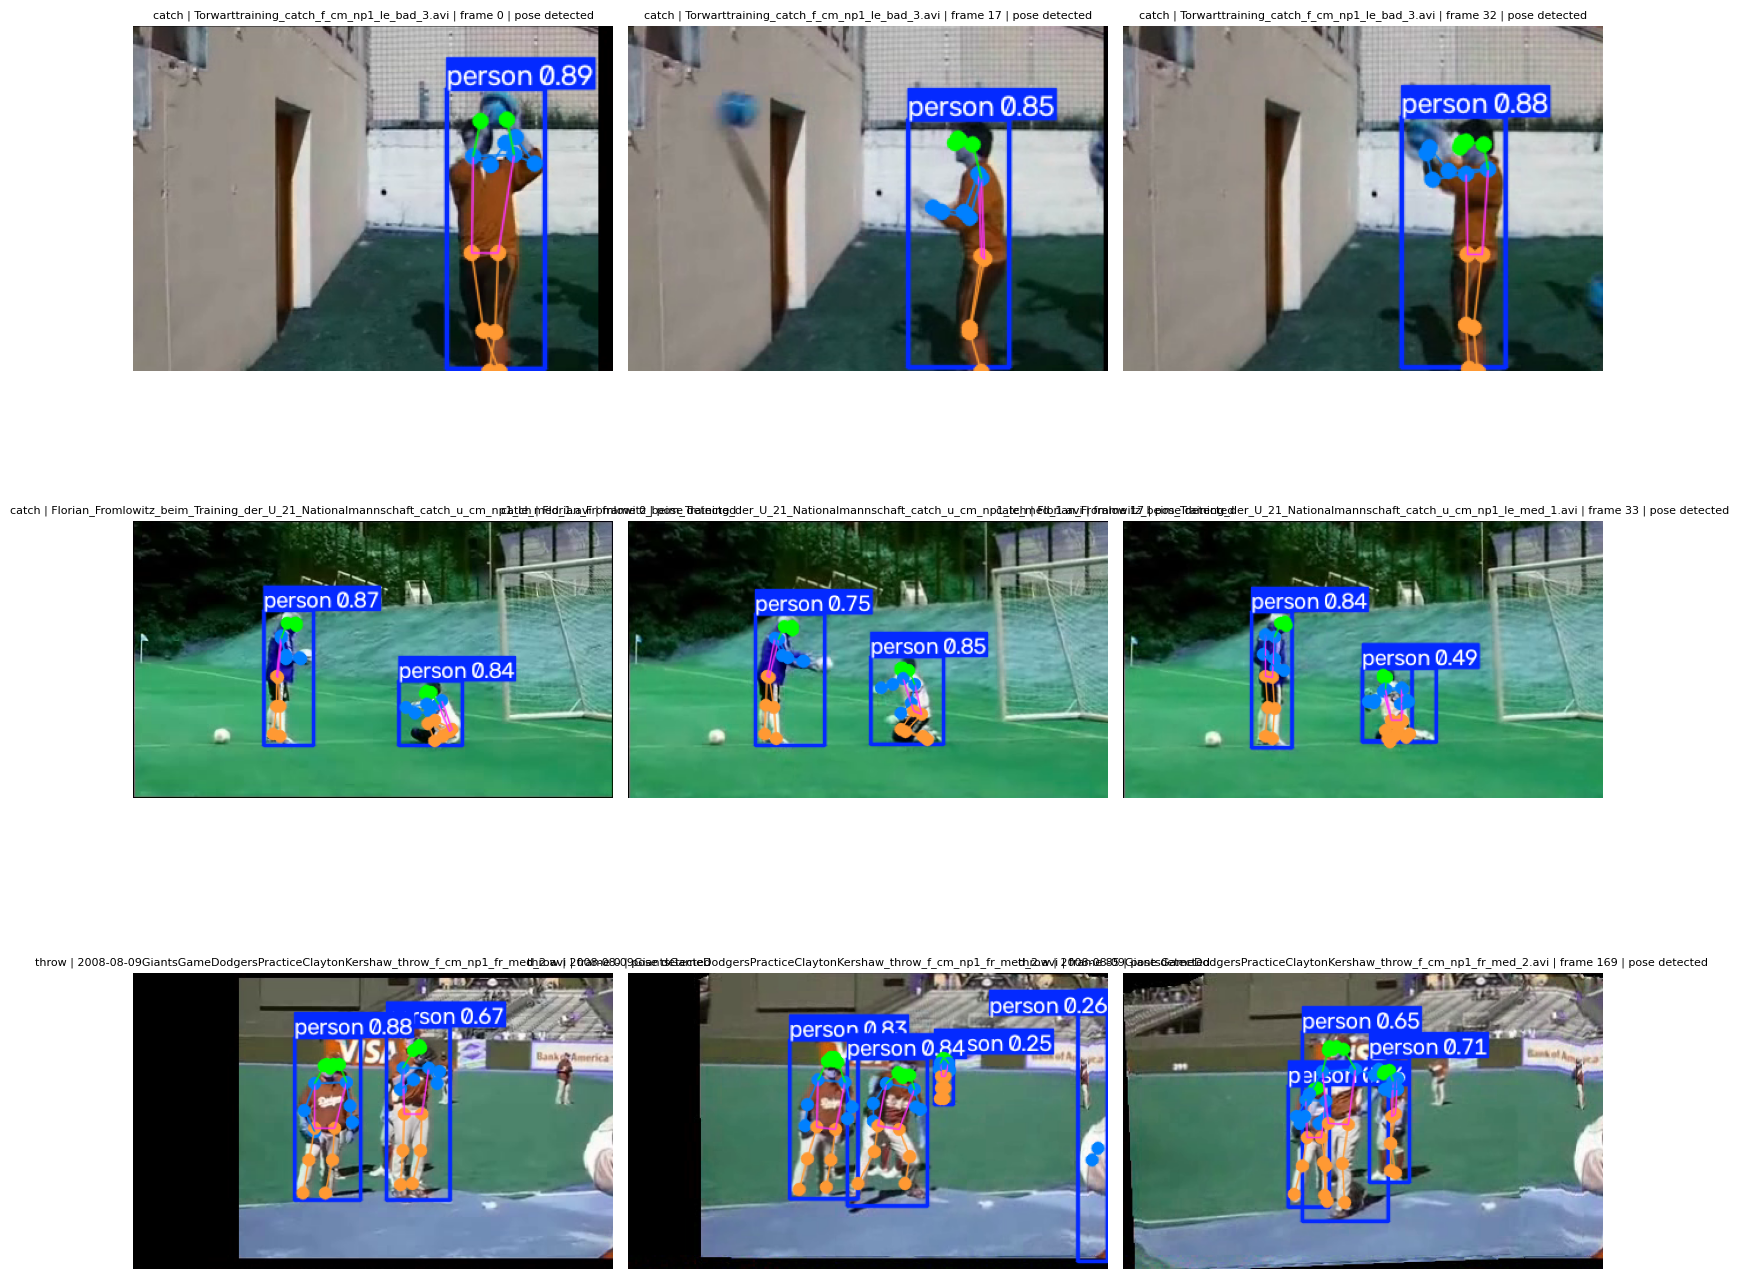

Saved: /content/drive/MyDrive/SIH26174/training/reports/pose_detection_examples.png


In [11]:
def draw_yolov8_pose(result, frame_rgb):
    annotated = frame_rgb.copy()
    if result is None:
        return annotated

    # Ultralytics provides a robust plot() method for boxes + keypoints.
    try:
        plotted_bgr = result.plot(labels=True, boxes=True, conf=True)
        return cv2.cvtColor(plotted_bgr, cv2.COLOR_BGR2RGB)
    except Exception:
        return annotated

frames_to_show = pose_raw_results[:MAX_VISUALIZED_FRAMES]
if not frames_to_show:
    print("No readable frames/results available to visualize.")
else:
    cols = min(3, len(frames_to_show))
    rows = (len(frames_to_show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, item in zip(axes, frames_to_show):
        annotated = draw_yolov8_pose(item["result"], item["frame_rgb"])
        detected = len(item["result"].boxes) > 0 if item["result"].boxes is not None else False
        title = (
            f"{item['hmdb51_action_class']} | {Path(item['video_path']).name} | "
            f"frame {item['frame_idx']} | {'pose detected' if detected else 'no pose'}"
        )
        ax.imshow(annotated)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    for ax in axes[len(frames_to_show):]:
        ax.axis("off")

    plt.tight_layout()
    pose_plot_path = REPORTS_DIR / "pose_detection_examples.png"
    plt.savefig(pose_plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", pose_plot_path)


## 13. Hand / Wrist Boundary

In [12]:
print("YOLOv8-Pose hand status: NO DEDICATED HAND LANDMARK MODEL")
print("YOLOv8-Pose exposes COCO wrist keypoints as part of body pose.")
print("It does not provide MediaPipe-style 21-point hand landmarks.")
print("Hand detection rate is therefore reported as N/A rather than fabricated.")

hand_summary = {
    "hand_model": None,
    "hands_detected": None,
    "hand_detection_rate": None,
    "reason": "YOLOv8-Pose is a body-pose model; it provides wrist keypoints but not dedicated hand landmarks."
}


YOLOv8-Pose hand status: NO DEDICATED HAND LANDMARK MODEL
YOLOv8-Pose exposes COCO wrist keypoints as part of body pose.
It does not provide MediaPipe-style 21-point hand landmarks.
Hand detection rate is therefore reported as N/A rather than fabricated.


## 14. Calculate Baseline Detection Statistics

In [13]:
num_frames_tested = len(pose_df)
frames_with_pose = int(pose_df["pose_detected"].sum()) if num_frames_tested else 0
pose_detection_rate = frames_with_pose / num_frames_tested if num_frames_tested else 0.0

frames_with_person = int((pose_df["person_count"] > 0).sum()) if num_frames_tested else 0
person_detection_rate = frames_with_person / num_frames_tested if num_frames_tested else 0.0

avg_detections_per_frame = float(pose_df["person_count"].mean()) if num_frames_tested else 0.0
avg_keypoint_confidence = float(pose_df["mean_keypoint_confidence"].dropna().mean()) if pose_df["mean_keypoint_confidence"].notna().any() else None

print(f"Frames tested                    : {num_frames_tested}")
print(f"Frames with pose/person         : {frames_with_pose}")
print(f"Pose detection rate             : {pose_detection_rate:.1%}")
print(f"Frames with person              : {frames_with_person}")
print(f"Person detection rate           : {person_detection_rate:.1%}")
print(f"Average persons per frame       : {avg_detections_per_frame:.3f}")
print(f"Average keypoint confidence     : {avg_keypoint_confidence:.4f}" if avg_keypoint_confidence is not None else "Average keypoint confidence     : N/A")
print("Dedicated hand detection rate  : N/A (not provided by YOLOv8-Pose)")

pose_by_class = (
    pose_df.groupby("hmdb51_action_class")["pose_detected"].mean().reindex(selected_classes).fillna(0.0)
    if not pose_df.empty else pd.Series(dtype=float)
)
print("\nPose detection rate by sampled class:")
print((pose_by_class * 100).round(1))


Frames tested                    : 54
Frames with pose/person         : 53
Pose detection rate             : 98.1%
Frames with person              : 53
Person detection rate           : 98.1%
Average persons per frame       : 2.352
Average keypoint confidence     : 0.5989
Dedicated hand detection rate  : N/A (not provided by YOLOv8-Pose)

Pose detection rate by sampled class:
hmdb51_action_class
catch          100.0
throw           83.3
clap           100.0
drink          100.0
eat            100.0
kick           100.0
kick_ball      100.0
wave           100.0
shake_hands    100.0
Name: pose_detected, dtype: float64


## 15. Timing

In [14]:
total_pose_seconds = float(sum(pose_timings))
avg_pose_seconds = total_pose_seconds / len(pose_timings) if pose_timings else 0.0
approx_pose_fps = 1.0 / avg_pose_seconds if avg_pose_seconds > 0 else 0.0

print(f"Timed pose frames            : {len(pose_timings)}")
print(f"Total pose inference time   : {total_pose_seconds:.3f}s")
print(f"Average pose time/frame     : {avg_pose_seconds * 1000:.1f} ms")
print(f"Approximate pose FPS        : {approx_pose_fps:.1f}")
print("Timing is indicative and includes runtime/model warm-up effects.")


Timed pose frames            : 54
Total pose inference time   : 8.839s
Average pose time/frame     : 163.7 ms
Approximate pose FPS        : 6.1
Timing is indicative and includes runtime/model warm-up effects.


## 16. Save detection tables

In [15]:
pose_csv_path = REPORTS_DIR / "yolov8_pose_detection_results.csv"
pose_df.to_csv(pose_csv_path, index=False)

print("Saved pose results:", pose_csv_path)


Saved pose results: /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_detection_results.csv


## 17. Limitations

In [16]:
limitation_notes = [
    "This is a pretrained YOLOv8-Pose COCO baseline; no pose model was trained or fine-tuned.",
    "HMDB51 is an action-recognition dataset, not a laboratory-specific pose/hand dataset.",
    "Pose/person detection availability is not the same as landmark accuracy.",
    "YOLOv8-Pose does not classify HMDB51 action classes and does not verify temporal sequence correctness.",
    "YOLOv8-Pose provides body keypoints including wrists, but it is not a dedicated 21-point hand landmark detector.",
    "Successful pose detection on HMDB51 does not establish suitability for the final SIH laboratory setup.",
    "If the final application needs lab-specific objects or interaction-aware pose behavior, custom data and fine-tuning may be required.",
    "Sequence validation must be performed later using a state machine combining pose/hand evidence, YOLO object/person detections, action-model probabilities, and temporal/order rules.",
]
for note in limitation_notes:
    print("-", note)


- This is a pretrained YOLOv8-Pose COCO baseline; no pose model was trained or fine-tuned.
- HMDB51 is an action-recognition dataset, not a laboratory-specific pose/hand dataset.
- Pose/person detection availability is not the same as landmark accuracy.
- YOLOv8-Pose does not classify HMDB51 action classes and does not verify temporal sequence correctness.
- YOLOv8-Pose provides body keypoints including wrists, but it is not a dedicated 21-point hand landmark detector.
- Successful pose detection on HMDB51 does not establish suitability for the final SIH laboratory setup.
- If the final application needs lab-specific objects or interaction-aware pose behavior, custom data and fine-tuning may be required.
- Sequence validation must be performed later using a state machine combining pose/hand evidence, YOLO object/person detections, action-model probabilities, and temporal/order rules.


## 18. Save JSON + Markdown reports

In [17]:
timestamp = datetime.now(timezone.utc).isoformat()

detected_classes = []
class_counts = Counter()
if not pose_raw_results:
    detected_classes = []
else:
    for raw in pose_raw_results:
        result = raw["result"]
        if result.boxes is None or len(result.boxes) == 0:
            continue
        for cls_id in result.boxes.cls.detach().cpu().numpy().astype(int).tolist():
            name = pose_model.names.get(int(cls_id), str(cls_id))
            class_counts[name] += 1
    detected_classes = sorted(class_counts)

report = {
    "notebook": "04_pose_hand_testing_YOLOV8_POSE.ipynb",
    "timestamp_utc": timestamp,
    "dataset_root": str(DATASET_ROOT),
    "python_version": sys.version,
    "ultralytics_version": ULTRALYTICS_VERSION,
    "yolo_pose": {
        "weights": YOLO_POSE_WEIGHTS,
        "confidence_threshold": YOLO_CONFIDENCE,
        "device": str(DEVICE),
        "keypoints": COCO_KEYPOINT_NAMES,
    },
    "sampling": {
        "random_seed": RANDOM_SEED,
        "preferred_classes": PREFERRED_SAMPLE_CLASSES,
        "selected_classes": selected_classes,
        "missing_preferred_classes": missing_preferred,
        "videos_per_class": VIDEOS_PER_CLASS,
        "frames_per_video": FRAMES_PER_VIDEO,
        "sample_videos": len(selected_video_records),
        "frames_tested": num_frames_tested,
        "unreadable_videos": unreadable_videos,
    },
    "pose_metrics": {
        "frames_with_pose": frames_with_pose,
        "pose_detection_rate": pose_detection_rate,
        "frames_with_person": frames_with_person,
        "person_detection_rate": person_detection_rate,
        "average_persons_per_frame": avg_detections_per_frame,
        "average_keypoint_confidence": avg_keypoint_confidence,
        "per_class_detection_rate": pose_by_class.to_dict(),
        "class_frequency_table": dict(class_counts),
        "distinct_detected_classes": detected_classes,
    },
    "hand_metrics": hand_summary,
    "timing": {
        "total_seconds": total_pose_seconds,
        "avg_seconds_per_frame": avg_pose_seconds,
        "approx_fps": approx_pose_fps,
    },
    "limitations": limitation_notes,
    "output_artifacts": {
        "sampled_frame_metadata": str(frame_metadata_path),
        "pose_results_csv": str(pose_csv_path),
        "pose_visualization": str(REPORTS_DIR / "pose_detection_examples.png"),
        "json_report": str(REPORTS_DIR / "yolov8_pose_test.json"),
        "markdown_report": str(REPORTS_DIR / "yolov8_pose_test.md"),
    },
}

json_path = REPORTS_DIR / "yolov8_pose_test.json"
with open(json_path, "w") as f:
    json.dump(report, f, indent=2)

md_lines = [
    "# YOLOv8-Pose Baseline Test",
    "",
    "## Goal",
    "Test whether pretrained YOLOv8-Pose can produce usable body-pose detections on a small deterministic sample of HMDB51 frames.",
    "",
    "## Runtime / Configuration",
    f"- Dataset root: `{DATASET_ROOT}`",
    f"- Python: `{sys.version.split()[0]}`",
    f"- Ultralytics: `{ULTRALYTICS_VERSION}`",
    f"- Model: `{YOLO_POSE_WEIGHTS}`",
    f"- Confidence threshold: `{YOLO_CONFIDENCE}`",
    f"- Device: `{DEVICE}`",
    f"- Selected classes: `{selected_classes}`",
    "",
    "## Summary Metrics",
    f"- Frames tested: **{num_frames_tested}**",
    f"- Frames with pose/person: **{frames_with_pose}**",
    f"- Pose detection rate: **{pose_detection_rate:.1%}**",
    f"- Person detection rate: **{person_detection_rate:.1%}**",
    f"- Average persons/frame: **{avg_detections_per_frame:.3f}**",
    f"- Average keypoint confidence: **{avg_keypoint_confidence:.4f}**" if avg_keypoint_confidence is not None else "- Average keypoint confidence: **N/A**",
    f"- Dedicated hand detection: **N/A** — YOLOv8-Pose provides body keypoints/wrists, not dedicated hand landmarks.",
    f"- Approximate pose FPS: **{approx_pose_fps:.1f}**",
    "",
    "## Per-class Pose Detection Rate",
]
for cls, rate in pose_by_class.items():
    md_lines.append(f"- `{cls}`: {rate:.1%}")

md_lines += [
    "",
    "## Detected Object Classes",
    *(f"- `{name}`: {count}" for name, count in class_counts.most_common()),
    "" if class_counts else "- No object classes were reported from pose model boxes.",
    "",
    "## Limitations",
]
md_lines.extend(f"- {note}" for note in limitation_notes)
md_lines += [
    "",
    "## Conclusion",
    "This notebook establishes a pretrained YOLOv8-Pose feasibility baseline only. It does not establish final pose accuracy or sequence-validation capability for the SIH laboratory application.",
]

md_path = REPORTS_DIR / "yolov8_pose_test.md"
with open(md_path, "w") as f:
    f.write("\n".join(md_lines))

print("Saved JSON:", json_path)
print("Saved Markdown:", md_path)


Saved JSON: /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_test.json
Saved Markdown: /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_test.md


## 19. Integration Readiness

In [18]:
print("YOLOv8-Pose can provide later integration signals such as:")
print("  - person visible")
print("  - body pose detected")
print("  - wrist visible/confident")
print("  - shoulder/elbow geometry")
print("  - approximate human pose context")
print()
print("YOLOv8-Pose alone does NOT provide:")
print("  - catch/not-catch classification")
print("  - dedicated hand landmarks")
print("  - temporal ordering / sequence correctness")
print("  - VALID/INVALID experiment decisions")
print()
print("Later integration should combine:")
print("  YOLO object/person detections + pose/wrist evidence + action-model probabilities + state-machine rules")
print()
print("If a dedicated hand model is unavailable, the system can still operate with YOLO + action recognition, but the sequence decision is weaker.")


YOLOv8-Pose can provide later integration signals such as:
  - person visible
  - body pose detected
  - wrist visible/confident
  - shoulder/elbow geometry
  - approximate human pose context

YOLOv8-Pose alone does NOT provide:
  - catch/not-catch classification
  - dedicated hand landmarks
  - temporal ordering / sequence correctness
  - VALID/INVALID experiment decisions

Later integration should combine:
  YOLO object/person detections + pose/wrist evidence + action-model probabilities + state-machine rules

If a dedicated hand model is unavailable, the system can still operate with YOLO + action recognition, but the sequence decision is weaker.


## 20. Final Summary

In [19]:
print("=" * 76)
print("NOTEBOOK 04 - POSE / HAND TESTING - YOLOV8-POSE FINAL SUMMARY")
print("=" * 76)
print(f"Dataset root                 : {DATASET_ROOT}")
print(f"Python version               : {sys.version.split()[0]}")
print(f"Ultralytics version          : {ULTRALYTICS_VERSION}")
print(f"YOLO pose model              : {YOLO_POSE_WEIGHTS}")
print(f"Confidence threshold         : {YOLO_CONFIDENCE}")
print(f"Device                       : {DEVICE}")
print(f"Frames tested                : {num_frames_tested}")
print(f"Pose detection rate          : {pose_detection_rate:.1%}")
print("Dedicated hand detection     : N/A (YOLOv8-Pose body model; wrists only)")
print(f"Detected box classes         : {detected_classes}")
print("Report paths:")
print(f"  - {json_path}")
print(f"  - {md_path}")
print(f"  - {pose_csv_path}")
print(f"  - {REPORTS_DIR / 'pose_detection_examples.png'}")
print()
print("STATUS: PRETRAINED YOLOv8-POSE BASELINE TEST COMPLETE")
print("=" * 76)


NOTEBOOK 04 - POSE / HAND TESTING - YOLOV8-POSE FINAL SUMMARY
Dataset root                 : /content/drive/MyDrive/SIH26174/training/data/raw/hmdb51_sta
Python version               : 3.13.15
Ultralytics version          : 8.4.141
YOLO pose model              : yolov8n-pose.pt
Confidence threshold         : 0.25
Device                       : 0
Frames tested                : 54
Pose detection rate          : 98.1%
Dedicated hand detection     : N/A (YOLOv8-Pose body model; wrists only)
Detected box classes         : ['person']
Report paths:
  - /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_test.json
  - /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_test.md
  - /content/drive/MyDrive/SIH26174/training/reports/yolov8_pose_detection_results.csv
  - /content/drive/MyDrive/SIH26174/training/reports/pose_detection_examples.png

STATUS: PRETRAINED YOLOv8-POSE BASELINE TEST COMPLETE
